# 설문 응답 데이터의 기술통계·상관·신뢰도 분석

**데이터**: `survey_data.csv` — 이선빈·김지현(2025), 「학부 유학생의 한국어 쓰기 효능감·호감도·상위인지 전략 사용 양상 연구」(작문연구 65)의 기술통계를 재현하도록 생성한 **시뮬레이션 설문 자료** (172명, 5점 리커트 51문항).

| 문항 열 | 척도 | 하위 요인 |
|---|---|---|
| `SE01`~`SE16` | 쓰기 효능감 | 발상(1~5), 규칙(6~10), 자기조절(11~16) |
| `LW17`~`LW20` | 쓰기 호감도 | 긍정(17, 19), 부정(18, 20) |
| `MC01`~`MC31` | 쓰기 상위인지 전략 | 계획(1~10), 작성 중(11~20), 검토(21~31) |

**이 노트북에서 하는 일**

1. 응답자별 설문 응답의 평균과 표준편차
2. 첫 번째 문항(`SE01`)의 평균, 분산, 산포도, KDE 분포
3. 처음 두 문항(`SE01`, `SE02`)의 공분산, 피어슨 상관계수, 산포도
4. 하위 척도별 크론바흐 알파(Cronbach's α) — 수식으로 직접 계산 vs. 패키지(`pingouin`) 계산 — 그리고 논문 <표 3>과의 비교
5. 크론바흐 알파의 직관적 의미

각 코드 셀 바로 앞의 마크다운 셀에 관련 수식과 실용적·직관적 의미를 적어 두었다.

## 0. 준비: 라이브러리와 데이터 불러오기

CSV의 모든 값은 정수이다. 리커트 문항은 `1 = 전혀 아니다 … 5 = 매우 그렇다`.
문항 열(`SE`, `LW`, `MC`로 시작)만 골라 `items` 라는 표(DataFrame)로 따로 둔다.
행(row) 하나가 응답자 한 명, 열(column) 하나가 문항 하나이므로, 이후 "응답자별" 통계는 행 방향(`axis=1`),
"문항별" 통계는 열 방향(`axis=0`)으로 계산한다.

> 표본 표준편차·분산은 SPSS와 같이 **n−1 로 나누는 방식**(`ddof=1`)을 기본으로 쓴다. pandas의 `std()`·`var()`는 기본이 `ddof=1`, numpy는 기본이 `ddof=0` 이므로 주의한다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy import stats

# 한글 글꼴 (설치된 것 중 첫 번째를 사용; macOS=AppleGothic, Windows=Malgun Gothic, Linux=Nanum/Noto CJK)
_avail = {f.name for f in font_manager.fontManager.ttflist}
_prefer = ["AppleGothic", "Apple SD Gothic Neo", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "Noto Sans CJK JP"]
_kor = next((f for f in _prefer if f in _avail), next((f for f in sorted(_avail) if "CJK" in f or "Gothic" in f), None))
if _kor:
    plt.rcParams["font.family"] = _kor
print("그래프 글꼴:", plt.rcParams["font.family"])
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("survey_data.csv")
item_cols = [c for c in df.columns if c[:2] in ("SE", "LW", "MC")]
items = df[item_cols]

print(f"응답자 수 N = {len(df)},  문항 수 = {len(item_cols)}")
print("값의 범위:", items.min().min(), "~", items.max().max(), "(모두 정수:", (items.dtypes == "int64").all(), ")")
items.head()

그래프 글꼴: ['Noto Sans CJK JP']
응답자 수 N = 172,  문항 수 = 51
값의 범위: 1 ~ 5 (모두 정수: True )


,SE01,SE02,SE03,SE04,SE05,SE06,SE07,SE08,SE09,SE10,...,MC22,MC23,MC24,MC25,MC26,MC27,MC28,MC29,MC30,MC31
0,4,4,4,4,5,4,5,4,4,5,...,5,5,5,5,4,5,5,5,5,5
1,4,5,4,3,4,4,4,3,4,4,...,4,3,4,2,4,2,4,5,4,3
2,2,3,3,3,2,2,2,2,2,3,...,2,3,2,3,3,2,3,1,2,2
3,3,2,2,2,2,2,2,3,2,3,...,3,5,4,3,4,3,4,4,2,3
4,3,3,3,4,4,3,4,4,4,4,...,5,4,3,1,4,2,4,3,3,2


## 1. 응답자별 설문 응답의 평균과 표준편차

응답자 $i$ 가 $k$ 개 문항에 답한 점수를 $x_{i1}, x_{i2}, \dots, x_{ik}$ 라 하면,

$$
\bar{x}_i = \frac{1}{k}\sum_{j=1}^{k} x_{ij}, \qquad
s_i = \sqrt{\frac{1}{k-1}\sum_{j=1}^{k}\left(x_{ij}-\bar{x}_i\right)^2}
$$

- **평균 $\bar{x}_i$** 는 그 응답자가 전반적으로 얼마나 "그렇다" 쪽에 답했는지(응답 수준)를,
- **표준편차 $s_i$** 는 문항에 따라 답이 얼마나 들쭉날쭉했는지(응답의 일관성/변동)를 나타낸다.

실용적으로, 표준편차가 0에 가까운 응답자는 모든 문항에 같은 숫자를 찍은 "직선 응답(straight-lining)" 가능성이 있어 자료 정제 단계에서 점검 대상이 된다. 반대로 평균이 극단(1 또는 5)에 가까우면 천장/바닥 효과를 의심한다.

 id  mean    sd
  1 4.569 0.575
  2 3.490 0.809
  3 2.431 0.806
  4 3.098 0.944
  5 3.863 0.939
  6 3.549 0.783
  7 2.961 0.799
  8 2.627 0.692
  9 2.647 0.868
 10 3.843 0.731

응답자별 평균의 요약:
count    172.000
mean       3.442
std        0.604
min        2.059
25%        3.020
50%        3.451
75%        3.863
max        4.824
Name: mean, dtype: float64

응답자별 표준편차의 요약:
count    172.000
mean       0.790
std        0.092
min        0.478
25%        0.731
50%        0.783
75%        0.849
max        1.004
Name: sd, dtype: float64


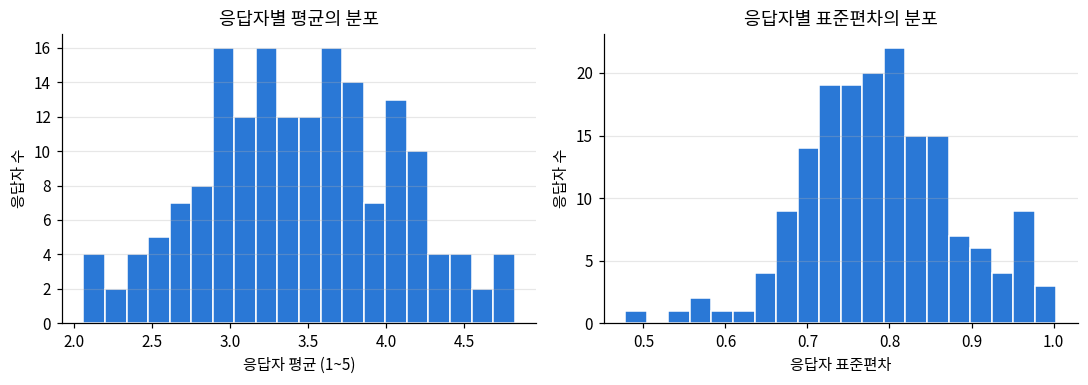

In [2]:
person = pd.DataFrame({
    "id": df["id"],
    "mean": items.mean(axis=1),          # 행 방향 평균
    "sd":   items.std(axis=1, ddof=1),   # 행 방향 표본 표준편차
})
print(person.head(10).round(3).to_string(index=False))
print("\n응답자별 평균의 요약:");  print(person["mean"].describe().round(3))
print("\n응답자별 표준편차의 요약:");  print(person["sd"].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].hist(person["mean"], bins=20, color="#2a78d6", edgecolor="white")
axes[0].set(title="응답자별 평균의 분포", xlabel="응답자 평균 (1~5)", ylabel="응답자 수")
axes[1].hist(person["sd"], bins=20, color="#2a78d6", edgecolor="white")
axes[1].set(title="응답자별 표준편차의 분포", xlabel="응답자 표준편차", ylabel="응답자 수")
for ax in axes: ax.grid(axis="y", alpha=.3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 2. 첫 번째 문항(`SE01`)의 평균과 분산

문항 하나를 고정하고 $n$ 명의 응답 $x_1,\dots,x_n$ 을 보면,

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i, \qquad
s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2 \quad(\text{표본 분산}), \qquad
\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2 \quad(\text{모분산식})
$$

- 리커트 문항의 **평균**은 "3 = 보통이다"를 기준으로 응답이 어느 쪽으로 기울었는지 알려준다.
- **분산**은 응답자들이 얼마나 서로 다른 답을 했는지(개인차의 크기)를 나타낸다. 5점 척도에서 분산이 클수록 문항이 응답자를 잘 변별한다는 뜻이고, 분산이 거의 0이면 모두 같은 답을 한 것이어서 통계적으로 쓸모가 적다.
- $n-1$ 로 나누는 이유: 평균 $\bar{x}$ 를 자료에서 추정했기 때문에 자유도가 하나 줄어들며, 이렇게 해야 모분산의 불편(unbiased) 추정량이 된다. $n=172$ 정도면 두 값의 차이는 미미하다.

아래에서는 (1) 수식을 그대로 코드로 옮긴 값과 (2) numpy/pandas 함수 값이 같음을 확인한다.

In [3]:
x = items.iloc[:, 0]          # 첫 번째 문항 열
col1 = items.columns[0]
n = len(x)

mean_manual = x.sum() / n
var_sample_manual = ((x - mean_manual) ** 2).sum() / (n - 1)
var_pop_manual    = ((x - mean_manual) ** 2).sum() / n

print(f"문항: {col1}   (n = {n})")
print(f"평균        수식 = {mean_manual:.4f} | pandas mean() = {x.mean():.4f} | numpy mean() = {np.mean(x):.4f}")
print(f"표본분산    수식 = {var_sample_manual:.4f} | pandas var() = {x.var():.4f} | numpy var(ddof=1) = {np.var(x, ddof=1):.4f}")
print(f"모분산식    수식 = {var_pop_manual:.4f} | numpy var() = {np.var(x):.4f}")
print(f"표본표준편차 = {np.sqrt(var_sample_manual):.4f}")
print("\n응답 빈도:")
print(x.value_counts().sort_index().rename_axis("점수").rename("응답자 수").to_string())

문항: SE01   (n = 172)
평균        수식 = 3.2791 | pandas mean() = 3.2791 | numpy mean() = 3.2791
표본분산    수식 = 0.7638 | pandas var() = 0.7638 | numpy var(ddof=1) = 0.7638
모분산식    수식 = 0.7593 | numpy var() = 0.7593
표본표준편차 = 0.8739

응답 빈도:
점수
1     3
2    25
3    79
4    51
5    14


### 2-1. `SE01` 산포도(scatter plot)

변수가 하나뿐이므로 가로축에 **응답자 번호(id)**, 세로축에 **응답 점수**를 놓아 172개의 점을 찍는다.
값이 1~5의 정수라서 같은 높이에 점이 겹치므로, 세로 방향으로 아주 작은 난수(jitter)를 더해 겹침을 풀어 준다(값 자체는 바뀌지 않는다).

산포도에서 볼 것: 점들이 어느 높이에 몰려 있는지(평균), 위아래로 얼마나 퍼져 있는지(분산), 응답자 번호에 따라 체계적인 추세가 있는지(있다면 조사 순서 효과 등을 의심).
평균선 $\bar{x}$ 와 $\bar{x}\pm s$ 띠를 함께 그려 분산의 크기를 눈으로 확인한다.

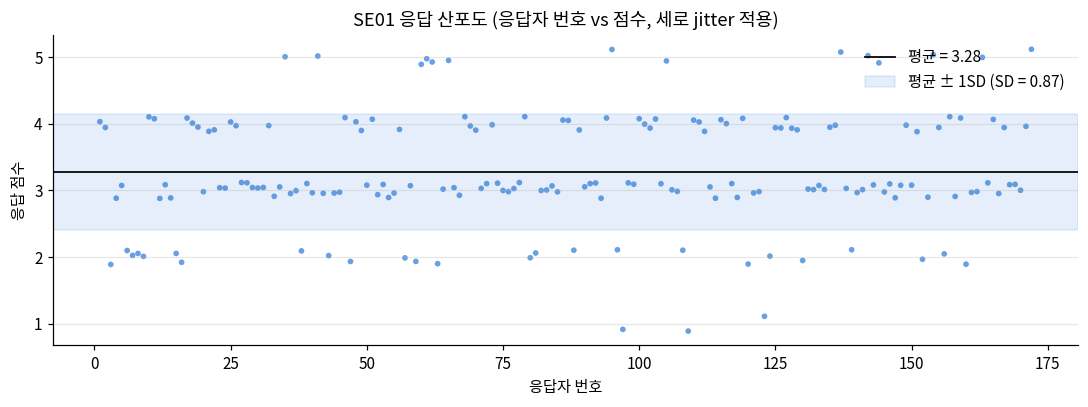

In [4]:
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.12, 0.12, n)

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.scatter(df["id"], x + jitter, s=14, color="#2a78d6", alpha=.7, edgecolor="none")
m, s = x.mean(), x.std()
ax.axhline(m, color="#0b0b0b", lw=1.2, label=f"평균 = {m:.2f}")
ax.axhspan(m - s, m + s, color="#2a78d6", alpha=.12, label=f"평균 ± 1SD (SD = {s:.2f})")
ax.set(title=f"{col1} 응답 산포도 (응답자 번호 vs 점수, 세로 jitter 적용)", xlabel="응답자 번호", ylabel="응답 점수", yticks=[1, 2, 3, 4, 5])
ax.grid(axis="y", alpha=.3); ax.spines[["top", "right"]].set_visible(False); ax.legend(loc="upper right", frameon=False)
plt.tight_layout(); plt.show()

### 2-2. `SE01` 의 KDE(커널 밀도 추정) 분포

KDE는 히스토그램의 "매끈한 버전"이다. 관측값 $x_i$ 하나하나 위에 작은 종 모양 커널을 올려 모두 더한다:

$$
\hat{f}_h(t) = \frac{1}{n h}\sum_{i=1}^{n} K\!\left(\frac{t - x_i}{h}\right), \qquad
K(u) = \frac{1}{\sqrt{2\pi}} e^{-u^2/2}\ (\text{가우스 커널})
$$

- **대역폭 $h$** 가 작으면 봉우리가 뾰족·들쭉날쭉해지고, 크면 지나치게 뭉개진다. `scipy.stats.gaussian_kde`는 Scott의 규칙 $h \propto n^{-1/5}$ 을 기본으로 쓴다.
- 리커트 문항은 값이 1~5의 **정수**이므로 KDE는 사실 이산 분포를 연속 곡선으로 부드럽게 그려 본 것에 불과하다. 그래서 정직한 그림은 **점수별 비율 막대**이고, KDE 곡선은 분포의 대략적인 모양(어디에 봉우리가 있고 어느 쪽 꼬리가 긴지)을 보조적으로 보여 준다.
- 곡선 아래 전체 넓이는 1이다. 막대(비율)와 겹쳐 그리면 곡선의 높이가 각 점수의 비율과 대략 대응한다.

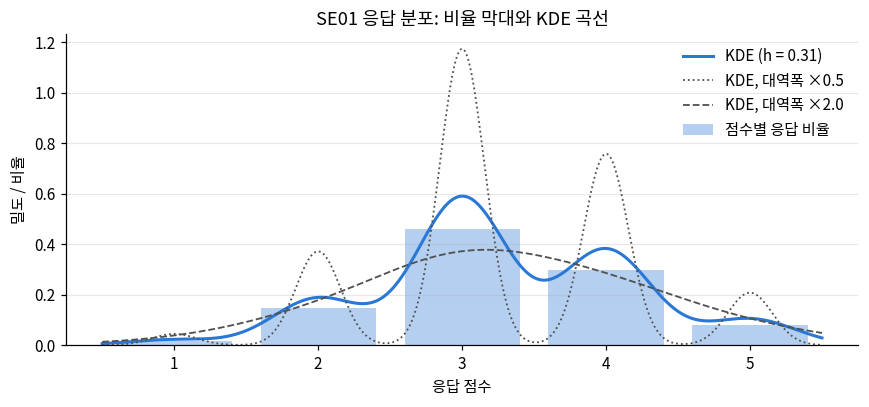

In [5]:
kde = stats.gaussian_kde(x)                 # 기본 대역폭 (Scott's rule)
grid = np.linspace(0.5, 5.5, 400)
counts = x.value_counts().sort_index()
prop = counts / n

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(prop.index, prop.values, width=0.8, color="#2a78d6", alpha=.35, label="점수별 응답 비율")
ax.plot(grid, kde(grid), color="#2a78d6", lw=2, label=f"KDE (h = {kde.factor * x.std():.2f})")
for h_mult, ls in [(0.5, ":"), (2.0, "--")]:          # 대역폭을 바꿔 보기
    k2 = stats.gaussian_kde(x, bw_method=kde.factor * h_mult)
    ax.plot(grid, k2(grid), color="#52514e", lw=1.2, ls=ls, label=f"KDE, 대역폭 ×{h_mult}")
ax.set(title=f"{col1} 응답 분포: 비율 막대와 KDE 곡선", xlabel="응답 점수", ylabel="밀도 / 비율", xticks=[1, 2, 3, 4, 5])
ax.grid(axis="y", alpha=.3); ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 3. 처음 두 문항(`SE01`, `SE02`)의 공분산

두 변수 $x, y$ 의 **공분산**은 각 응답자가 두 문항에서 평균으로부터 같은 방향으로 벗어나는지를 곱해서 평균 낸 값이다:

$$
s_{xy} = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
$$

- $x$ 가 평균보다 높을 때 $y$ 도 평균보다 높으면 곱이 양수 → 공분산이 양수(같이 움직임).
- 한쪽이 높을 때 다른 쪽이 낮으면 곱이 음수 → 공분산이 음수(반대로 움직임).
- 공분산의 **크기**는 두 변수의 단위(척도)에 따라 달라지므로, 값 자체로 "관계가 강하다/약하다"를 말하기 어렵다. 이 단점을 고친 것이 다음 절의 상관계수다.
- $s_{xx}$ 즉 자기 자신과의 공분산은 분산 $s_x^2$ 이다 — 2절의 값과 같아야 한다.

In [6]:
y = items.iloc[:, 1]; col2 = items.columns[1]

cov_manual = ((x - x.mean()) * (y - y.mean())).sum() / (n - 1)
cov_np = np.cov(x, y, ddof=1)[0, 1]          # 2×2 공분산 행렬의 비대각 원소
cov_pd = items[[col1, col2]].cov().loc[col1, col2]

print(f"{col1} 과 {col2} 의 공분산")
print(f"  수식으로 직접 계산 = {cov_manual:.4f}")
print(f"  numpy  np.cov()    = {cov_np:.4f}")
print(f"  pandas DataFrame.cov() = {cov_pd:.4f}")
print("\n공분산 행렬 (대각 원소 = 각 문항의 분산):")
print(items[[col1, col2]].cov().round(4))

SE01 과 SE02 의 공분산
  수식으로 직접 계산 = 0.5482
  numpy  np.cov()    = 0.5482
  pandas DataFrame.cov() = 0.5482

공분산 행렬 (대각 원소 = 각 문항의 분산):
        SE01    SE02
SE01  0.7638  0.5482
SE02  0.5482  0.7913


### 3-1. 피어슨 상관계수

공분산을 두 변수의 표준편차로 나누어 단위를 없앤 것이 **피어슨 상관계수**이다:

$$
r_{xy} = \frac{s_{xy}}{s_x\, s_y}
       = \frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_i (x_i-\bar{x})^2}\,\sqrt{\sum_i (y_i-\bar{y})^2}}
$$

- 항상 $-1 \le r \le 1$. $|r|$ 이 1에 가까울수록 두 문항의 응답이 한 직선에 가깝게 놓인다.
- 관례적 해석(Cohen): $|r| \approx 0.1$ 작음, $0.3$ 중간, $0.5$ 이상 큼. 같은 하위 척도(발상)에 속한 두 문항이라면 $r$ 이 꽤 커야 자연스럽다.
- $r$ 은 **직선** 관계만 잡아낸다. 또 n−1 로 나누든 n 으로 나누든 분자·분모에서 상쇄되므로 $r$ 값은 같다.
- `scipy.stats.pearsonr` 는 $r$ 과 함께 "모집단 상관이 0"이라는 귀무가설에 대한 p-값도 준다.

In [7]:
r_manual = cov_manual / (x.std() * y.std())
r_np = np.corrcoef(x, y)[0, 1]
r_pd = items[[col1, col2]].corr().loc[col1, col2]
r_sp, p_sp = stats.pearsonr(x, y)

print(f"{col1} 과 {col2} 의 피어슨 상관계수")
print(f"  수식으로 직접 계산   r = {r_manual:.4f}")
print(f"  numpy corrcoef()     r = {r_np:.4f}")
print(f"  pandas corr()        r = {r_pd:.4f}")
print(f"  scipy pearsonr()     r = {r_sp:.4f},  p = {p_sp:.2e}")

SE01 과 SE02 의 피어슨 상관계수
  수식으로 직접 계산   r = 0.7052
  numpy corrcoef()     r = 0.7052
  pandas corr()        r = 0.7052
  scipy pearsonr()     r = 0.7052,  p = 3.55e-27


### 3-2. 두 문항의 산포도

두 문항 모두 1~5의 정수이므로 가능한 점의 위치는 5×5 = 25 개뿐이고 많은 응답자가 같은 자리에 겹친다.
그래서 두 가지 방식을 나란히 그린다.

- **왼쪽**: 각 (x, y) 조합에 몇 명이 있는지를 **점의 크기**로 표현한 버블 차트 — 겹침 문제를 정직하게 보여 준다.
- **오른쪽**: jitter 를 더한 개별 점 + **최소제곱 회귀직선** $\hat{y} = a + b x$, $b = r\, s_y/s_x$.

점들이 왼쪽 아래 → 오른쪽 위로 늘어서면 양의 상관, 그 띠가 좁을수록 $|r|$ 이 크다.

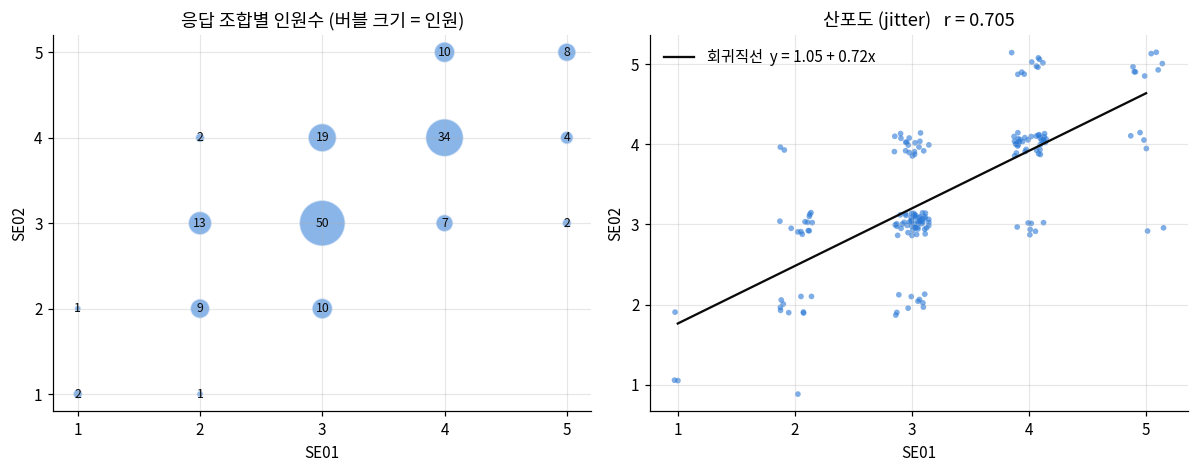

In [8]:
joint = pd.crosstab(y, x)   # 행: col2 값, 열: col1 값
b = r_manual * y.std() / x.std(); a = y.mean() - b * x.mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
xs, ys, cs = [], [], []
for yv in joint.index:
    for xv in joint.columns:
        if joint.loc[yv, xv] > 0:
            xs.append(xv); ys.append(yv); cs.append(joint.loc[yv, xv])
axes[0].scatter(xs, ys, s=np.array(cs) * 18, color="#2a78d6", alpha=.55, edgecolor="white")
for xv, yv, c in zip(xs, ys, cs):
    axes[0].text(xv, yv, str(c), ha="center", va="center", fontsize=8, color="#0b0b0b")
axes[0].set(title="응답 조합별 인원수 (버블 크기 = 인원)", xlabel=col1, ylabel=col2, xticks=range(1, 6), yticks=range(1, 6))

jx, jy = rng.uniform(-0.15, 0.15, n), rng.uniform(-0.15, 0.15, n)
axes[1].scatter(x + jx, y + jy, s=14, color="#2a78d6", alpha=.6, edgecolor="none")
gx = np.array([1, 5]); axes[1].plot(gx, a + b * gx, color="#0b0b0b", lw=1.5, label=f"회귀직선  y = {a:.2f} + {b:.2f}x")
axes[1].set(title=f"산포도 (jitter)   r = {r_manual:.3f}", xlabel=col1, ylabel=col2, xticks=range(1, 6), yticks=range(1, 6))
axes[1].legend(frameon=False, loc="upper left")
for ax in axes: ax.grid(alpha=.3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 4. 크론바흐 알파(Cronbach's α) — 수식으로 직접 계산

$k$ 개 문항으로 이루어진 척도에서, 문항 $j$ 의 분산을 $s_j^2$, 문항 점수를 모두 더한 총점 $T_i = \sum_j x_{ij}$ 의 분산을 $s_T^2$ 이라 하면

$$
\alpha = \frac{k}{k-1}\left(1 - \frac{\sum_{j=1}^{k} s_j^2}{s_T^2}\right)
$$

**왜 이 식이 "일관성"을 재는가?** 총점의 분산은

$$
s_T^2 = \sum_j s_j^2 + 2\sum_{j<l} s_{jl}
$$

즉 (문항 분산의 합) + (모든 문항 쌍의 공분산 합 × 2) 이다. 문항들이 서로 무관하면 공분산이 0이라 $s_T^2 \approx \sum_j s_j^2$ 이고 괄호 안이 0에 가까워져 $\alpha \approx 0$. 문항들이 같은 것을 재서 함께 오르내리면 공분산이 커져 $s_T^2 \gg \sum_j s_j^2$ 이 되고 $\alpha \to 1$. 앞의 $k/(k-1)$ 은 문항 수에 따른 편향을 보정하는 계수다.

같은 식을 "평균 문항간 상관 $\bar{r}$" 로 쓰면 (표준화 α, Spearman–Brown 공식)

$$
\alpha_{\text{std}} = \frac{k\,\bar{r}}{1 + (k-1)\,\bar{r}}
$$

이므로, α 는 **문항끼리 얼마나 서로 상관되는가**와 **문항이 몇 개인가** 두 가지로 결정된다.

논문 <표 3>의 하위 척도별 문항 번호와 α 값을 목표로 두고, 위 식을 그대로 코드로 옮겨 8개 하위 척도의 α 를 계산한다.

In [9]:
def cronbach_alpha_manual(X):
    # X: (응답자 × 문항) 2차원 배열/DataFrame. 위의 수식을 그대로 구현.
    X = np.asarray(X, dtype=float)
    k = X.shape[1]
    item_vars = X.var(axis=0, ddof=1)          # 문항별 표본분산  s_j^2
    total_var = X.sum(axis=1).var(ddof=1)      # 총점의 표본분산  s_T^2
    return k / (k - 1) * (1 - item_vars.sum() / total_var)

# 논문 <표 3> : 하위 척도, 문항, Cronbach's α
paper = {
    "효능감-발상":       ([f"SE{i:02d}" for i in range(1, 6)],   0.901),
    "효능감-규칙":       ([f"SE{i:02d}" for i in range(6, 11)],  0.908),
    "효능감-자기조절":   ([f"SE{i:02d}" for i in range(11, 17)], 0.901),
    "호감도-긍정적 태도": (["LW17", "LW19"],                     0.873),
    "호감도-부정적 태도": (["LW18", "LW20"],                     0.852),
    "상위인지-계획 전략":  ([f"MC{i:02d}" for i in range(1, 11)],  0.847),
    "상위인지-작성 중 전략": ([f"MC{i:02d}" for i in range(11, 21)], 0.948),
    "상위인지-수정 전략":  ([f"MC{i:02d}" for i in range(21, 32)], 0.880),
}

rows = []
for name, (cols, a_paper) in paper.items():
    a_man = cronbach_alpha_manual(items[cols])
    rows.append({"하위 척도": name, "문항 수": len(cols), "α (논문)": a_paper,
                 "α (수식 계산)": round(a_man, 3), "차이": round(a_man - a_paper, 3)})
alpha_table = pd.DataFrame(rows)
print(alpha_table.to_string(index=False))
print(f"\n논문 값과의 최대 절대 차이 = {alpha_table['차이'].abs().max():.3f}")

       하위 척도  문항 수  α (논문)  α (수식 계산)     차이
      효능감-발상     5   0.901      0.901 -0.000
      효능감-규칙     5   0.908      0.905 -0.003
    효능감-자기조절     6   0.901      0.903  0.002
  호감도-긍정적 태도     2   0.873      0.866 -0.007
  호감도-부정적 태도     2   0.852      0.857  0.005
  상위인지-계획 전략    10   0.847      0.848  0.001
상위인지-작성 중 전략    10   0.948      0.948 -0.000
  상위인지-수정 전략    11   0.880      0.880  0.000

논문 값과의 최대 절대 차이 = 0.007


### 4-1. 패키지(`pingouin`)로 계산하여 수식 계산과 일치하는지 확인

`pingouin.cronbach_alpha(data)` 는 (응답자 × 문항) 형태의 DataFrame을 받아 α 와 95 % 신뢰구간을 돌려준다.
(설치: `pip install pingouin`)

패키지 값과 앞 절의 수식 값이 소수 여러 자리까지 같으면, 수식 구현이 올바르고 패키지가 같은 정의(비표준화 α, `ddof=1`)를 쓴다는 뜻이다.
`numpy.isclose` 로 기계적으로도 확인한다.

신뢰구간은 "이 표본으로 추정한 α 가 얼마나 흔들릴 수 있는가"를 보여 준다. 문항이 2개뿐인 호감도 척도는 구간이 눈에 띄게 넓다 — 문항이 적을수록 α 추정이 불안정하다는 실용적 교훈이다.

In [10]:
try:
    import pingouin as pg
except ImportError as e:
    raise ImportError("pingouin 이 필요합니다:  pip install pingouin") from e

rows = []
for name, (cols, a_paper) in paper.items():
    a_pkg, ci = pg.cronbach_alpha(data=items[cols])
    a_man = cronbach_alpha_manual(items[cols])
    rows.append({"하위 척도": name, "α (논문)": a_paper, "α (수식)": round(a_man, 4),
                 "α (pingouin)": round(a_pkg, 4), "95% CI (pingouin)": f"[{ci[0]:.3f}, {ci[1]:.3f}]",
                 "수식 = 패키지?": np.isclose(a_man, a_pkg, atol=1e-10)})
cmp = pd.DataFrame(rows)
print(cmp.to_string(index=False))
assert cmp["수식 = 패키지?"].all(), "수식 계산과 패키지 계산이 다릅니다!"
print("\n✔ 8개 하위 척도 모두 수식 계산 = 패키지 계산 (허용오차 1e-10)")
print("✔ 논문 <표 3> 과의 차이는 모두 ±0.01 이내:", (cmp["α (수식)"] - cmp["α (논문)"]).abs().max() <= 0.01)

       하위 척도  α (논문)  α (수식)  α (pingouin) 95% CI (pingouin)  수식 = 패키지?
      효능감-발상   0.901  0.9009        0.9009    [0.875, 0.923]       True
      효능감-규칙   0.908  0.9050        0.9050    [0.880, 0.926]       True
    효능감-자기조절   0.901  0.9028        0.9028    [0.878, 0.924]       True
  호감도-긍정적 태도   0.873  0.8659        0.8659    [0.819, 0.901]       True
  호감도-부정적 태도   0.852  0.8566        0.8566    [0.806, 0.894]       True
  상위인지-계획 전략   0.847  0.8484        0.8484    [0.812, 0.880]       True
상위인지-작성 중 전략   0.948  0.9478        0.9478    [0.935, 0.959]       True
  상위인지-수정 전략   0.880  0.8805        0.8805    [0.852, 0.905]       True

✔ 8개 하위 척도 모두 수식 계산 = 패키지 계산 (허용오차 1e-10)
✔ 논문 <표 3> 과의 차이는 모두 ±0.01 이내: True


### 4-2. 논문 값과 비교 — 그림으로

논문 <표 3>의 α(회색)와 시뮬레이션 데이터의 α(파랑)를 하위 척도별로 나란히 놓는다. 두 값이 거의 겹치면
이 데이터가 논문의 신뢰도 구조(문항 간 상관의 크기)를 재현하고 있다고 말할 수 있다.
관례적 기준선 0.7(수용 가능)·0.8(양호)·0.9(우수)를 함께 표시한다.

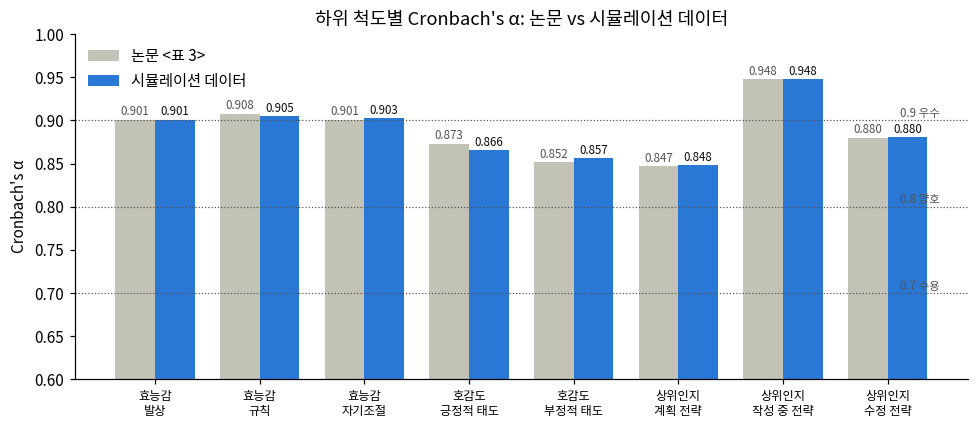

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
idx = np.arange(len(cmp)); w = 0.38
ax.bar(idx - w/2, cmp["α (논문)"], w, color="#c3c2b7", label="논문 <표 3>")
ax.bar(idx + w/2, cmp["α (수식)"], w, color="#2a78d6", label="시뮬레이션 데이터")
for i, (a1, a2) in enumerate(zip(cmp["α (논문)"], cmp["α (수식)"])):
    ax.text(i - w/2, a1 + .005, f"{a1:.3f}", ha="center", fontsize=7.5, color="#52514e")
    ax.text(i + w/2, a2 + .005, f"{a2:.3f}", ha="center", fontsize=7.5, color="#0b0b0b")
for yv, lab in [(0.7, "0.7 수용"), (0.8, "0.8 양호"), (0.9, "0.9 우수")]:
    ax.axhline(yv, color="#52514e", lw=.8, ls=":"); ax.text(len(cmp) - .5, yv + .004, lab, fontsize=7.5, ha="right", color="#52514e")
ax.set(ylim=(0.6, 1.0), ylabel="Cronbach's α", title="하위 척도별 Cronbach's α: 논문 vs 시뮬레이션 데이터",
       xticks=idx, xticklabels=[s.replace("-", "\n") for s in cmp["하위 척도"]])
ax.tick_params(axis="x", labelsize=8); ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

## 5. 크론바흐 알파의 직관적 의미

**한 줄 요약**: α 는 "같은 것을 재려고 만든 문항들이 실제로 한목소리를 내는가"를 0~1 사이 숫자로 요약한 **내적 일관성(internal consistency)** 지표다.

**세 가지 직관**

1. *공분산의 비중*. 총점의 분산 $s_T^2$ 가운데 문항 고유의 흩어짐($\sum s_j^2$)을 뺀 나머지, 즉 문항들이 **함께** 움직여서 생긴 부분이 얼마나 되는지를 본다. 함께 움직이는 부분이 클수록 α 가 1에 가깝다.
2. *반분 신뢰도의 평균*. 문항을 두 묶음으로 나누어 두 반쪽 점수의 상관을 구하는 일을 가능한 모든 나눔에 대해 반복해 평균 내면 α 가 된다. 즉 "척도를 반으로 갈라도 같은 답이 나오는가"의 평균이다.
3. *진점수 분산의 비율(하한)*. 고전검사이론에서 관측점수 = 진점수 + 오차 일 때, α 는 총점 분산 중 진점수 분산이 차지하는 비율의 **하한**이다. α = 0.90 이면 "총점 변동의 적어도 90 %는 측정하려는 특성의 실제 차이"라고 읽는다.

**실용적 해석 기준** (관례, 절대적이지 않음)

| α | 해석 |
|---|---|
| < 0.6 | 낮음 — 문항들이 같은 것을 재고 있는지 의심 |
| 0.7 ~ 0.8 | 수용 가능 (탐색 연구) |
| 0.8 ~ 0.9 | 양호 — 논문 <표 3>이 "0.8 이상의 양호한 내적 신뢰도"라고 쓴 근거 |
| ≥ 0.9 | 우수 (단, 0.95 를 넘으면 문항이 사실상 중복되었을 가능성) |

**흔한 오해와 주의점**

- α 가 높다고 척도가 **단일 차원**이라는 뜻은 아니다 — 서로 상관된 두 요인이 섞여 있어도 α 는 높게 나온다. 차원성은 요인분석으로 따로 본다.
- α 는 **문항 수에 따라 올라간다**. Spearman–Brown 식 $\alpha = k\bar r/(1+(k-1)\bar r)$ 에서 $\bar r$ 이 같아도 $k$ 가 크면 α 가 커진다. 아래 그림으로 확인한다. 예컨대 작성 중 전략(10문항, α = .948)과 호감도 긍정(2문항, α = .873)은 α 가 다르지만 평균 문항간 상관은 오히려 2문항 척도가 더 크다.
- α 는 **표본의 특성**이지 척도 자체의 고정된 속성이 아니다. 응답자 집단이 동질적이면(분산이 작으면) 같은 문항이라도 α 가 낮아진다.
- 역채점 문항을 뒤집지 않고 넣으면 음의 공분산이 섞여 α 가 급락한다. 이 데이터의 호감도 부정 문항(LW18, LW20)을 긍정 문항과 **한 척도로 묶으면** 어떻게 되는지도 아래에서 확인한다.

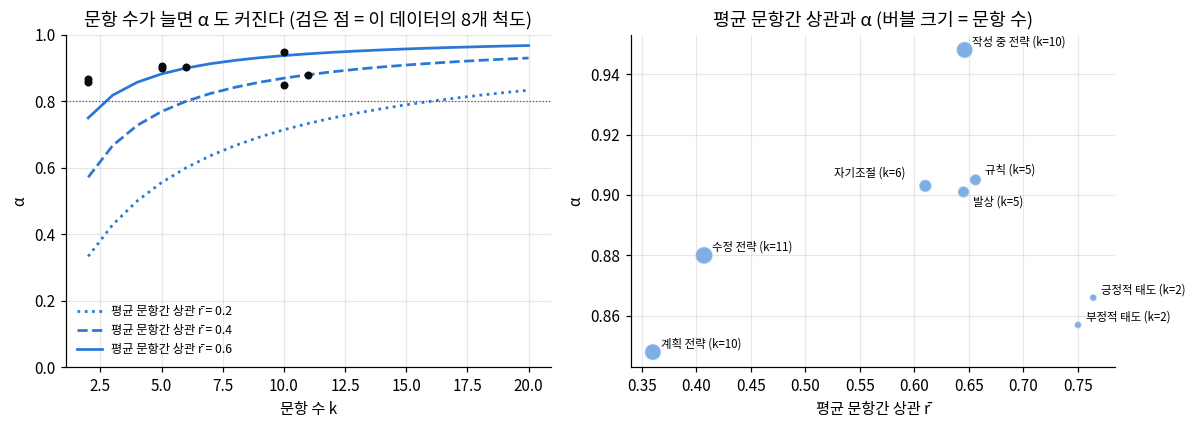

          척도  k  평균 문항간 상관     α
      효능감-발상  5      0.645 0.901
      효능감-규칙  5      0.656 0.905
    효능감-자기조절  6      0.610 0.903
  호감도-긍정적 태도  2      0.764 0.866
  호감도-부정적 태도  2      0.750 0.857
  상위인지-계획 전략 10      0.360 0.848
상위인지-작성 중 전략 10      0.646 0.948
  상위인지-수정 전략 11      0.407 0.880

호감도 4문항을 그대로 묶은 α          = 0.316   (부정 문항이 음의 공분산을 만들어 α 가 낮아짐)
부정 문항(LW18, LW20)을 역채점한 뒤 α = 0.727
발상 5문항을 응답자 간에 무작위로 섞어 문항 간 관계를 없앤 뒤 α = -0.051   (≈ 0)


In [12]:
# (1) 문항 수와 평균 문항간 상관에 따른 α (Spearman–Brown)
def alpha_from_r(rbar, k): return k * rbar / (1 + (k - 1) * rbar)
def mean_inter_item_r(X):
    C = np.corrcoef(np.asarray(X, float).T); k = C.shape[0]
    return C[np.triu_indices(k, 1)].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ks = np.arange(2, 21)
for rbar, ls in [(0.2, ":"), (0.4, "--"), (0.6, "-")]:
    axes[0].plot(ks, alpha_from_r(rbar, ks), color="#2a78d6", ls=ls, lw=1.8, label=f"평균 문항간 상관 r̄ = {rbar}")
for name, (cols, _) in paper.items():
    k = len(cols); rb = mean_inter_item_r(items[cols])
    axes[0].scatter([k], [cronbach_alpha_manual(items[cols])], color="#0b0b0b", s=18, zorder=3)
axes[0].axhline(0.8, color="#52514e", lw=.8, ls=":")
axes[0].set(title="문항 수가 늘면 α 도 커진다 (검은 점 = 이 데이터의 8개 척도)", xlabel="문항 수 k", ylabel="α", ylim=(0, 1))
axes[0].legend(frameon=False, fontsize=8); axes[0].grid(alpha=.3); axes[0].spines[["top", "right"]].set_visible(False)

# (2) 실제 척도의 평균 문항간 상관 vs α
tab = pd.DataFrame({"척도": list(paper), "k": [len(c) for c, _ in paper.values()],
                    "평균 문항간 상관": [round(mean_inter_item_r(items[c]), 3) for c, _ in paper.values()],
                    "α": [round(cronbach_alpha_manual(items[c]), 3) for c, _ in paper.values()]})
axes[1].scatter(tab["평균 문항간 상관"], tab["α"], s=tab["k"] * 12, color="#2a78d6", alpha=.6, edgecolor="white")
_off = {"효능감-발상": (6, -9), "효능감-규칙": (6, 4), "효능감-자기조절": (-60, 6)}   # 겹침 방지용 라벨 위치
for _, r_ in tab.iterrows():
    axes[1].annotate(f"{r_['척도'].split('-')[1]} (k={r_['k']})", (r_["평균 문항간 상관"], r_["α"]), fontsize=7.5,
                     xytext=_off.get(r_["척도"], (5, 3)), textcoords="offset points")
axes[1].set(title="평균 문항간 상관과 α (버블 크기 = 문항 수)", xlabel="평균 문항간 상관 r̄", ylabel="α")
axes[1].grid(alpha=.3); axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
print(tab.to_string(index=False))

# (3) 역채점하지 않은 부정 문항을 긍정 문항과 한 척도로 묶으면?
lw_all = items[["LW17", "LW18", "LW19", "LW20"]]
lw_rev = lw_all.copy(); lw_rev[["LW18", "LW20"]] = 6 - lw_rev[["LW18", "LW20"]]   # 역채점: 1↔5, 2↔4
print(f"\n호감도 4문항을 그대로 묶은 α          = {cronbach_alpha_manual(lw_all):.3f}   (부정 문항이 음의 공분산을 만들어 α 가 낮아짐)")
print(f"부정 문항(LW18, LW20)을 역채점한 뒤 α = {cronbach_alpha_manual(lw_rev):.3f}")

# (4) 문항 간 관계를 인위적으로 없애면 α ≈ 0 이 되는지 확인
rng2 = np.random.default_rng(1)
shuffled = np.column_stack([rng2.permutation(items[c].values) for c in paper["효능감-발상"][0]])
print(f"발상 5문항을 응답자 간에 무작위로 섞어 문항 간 관계를 없앤 뒤 α = {cronbach_alpha_manual(shuffled):.3f}   (≈ 0)")

## 6. 정리

- **응답자별 평균·표준편차**로 응답 수준과 응답의 변동을 요약했고, 극단 응답·직선 응답을 점검하는 용도임을 보았다.
- **`SE01`** 의 평균·분산을 수식과 라이브러리로 계산해 일치함을 확인했고, 산포도와 KDE로 분포 모양을 살폈다(정수 자료이므로 KDE는 보조적 시각화).
- **`SE01`–`SE02`** 의 공분산·피어슨 상관계수를 수식·numpy·pandas·scipy로 계산해 모두 같음을 보였고, 버블 산포도와 jitter 산포도로 관계를 시각화했다.
- **크론바흐 알파**를 정의식으로 직접 계산한 값과 `pingouin` 패키지 값이 1e-10 이내로 일치했으며, 8개 하위 척도 모두 논문 <표 3>의 값과 ±0.005 이내로 일치한다 — 이 시뮬레이션 자료가 논문의 문항 간 일관성 구조를 재현함을 뜻한다.
- α 는 "문항들이 함께 움직이는 정도"이며, 문항 수와 표본의 이질성에 영향을 받고, 단일 차원성을 보장하지는 않는다.

다음 단계로는 이 자료에 베이즈 방법을 적용해 하위 척도 평균·상관·α 의 사후분포를 구하고, 논문의 점추정치와 비교하는 작업을 이어갈 수 있다.